In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

# Explore data

In [3]:
df = pd.read_csv("fire_archive_M6_96619.csv",
                 usecols=["latitude", "longitude", "brightness", "acq_date"],
                 parse_dates=["acq_date"])

df.head()

,latitude,longitude,brightness,acq_date
0,-11.8070,142.0583,313.0,2019-08-01
1,-11.7924,142.0850,319.3,2019-08-01
2,-12.8398,132.8744,311.6,2019-08-01
3,-14.4306,143.3035,310.1,2019-08-01
4,-12.4953,131.4897,310.3,2019-08-01


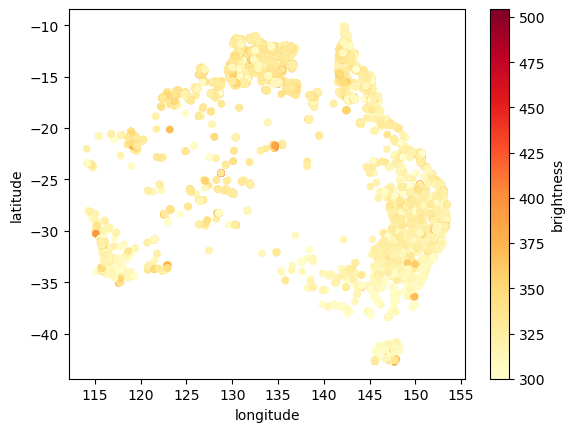

In [7]:
df.plot(x="longitude", y="latitude", kind="scatter", c="brightness", colormap="YlOrRd")
plt.show()

# Geopandas

In [9]:
gpd.datasets.available

[]

In [11]:
countries = gpd.read_file("https://d2ad6b4ur7yvpq.cloudfront.net/naturalearth-3.3.0/ne_50m_admin_0_countries.geojson")

countries.head()

,scalerank,labelrank,sovereignt,sov_a3,adm0_dif,level,type,admin,adm0_a3,geou_dif,...,region_un,subregion,region_wb,name_len,long_len,abbrev_len,tiny,homepart,featureclass,geometry
0,3,5,Netherlands,NL1,1,2,Country,Aruba,ABW,0,...,Americas,Caribbean,Latin America & Caribbean,5,5,5,4,-99,Admin-0 country,"POLYGON ((-69.89912 12.452, -69.8957 12.423, -..."
1,1,3,Afghanistan,AFG,0,2,Sovereign country,Afghanistan,AFG,0,...,Asia,Southern Asia,South Asia,11,11,4,-99,1,Admin-0 country,"POLYGON ((74.89131 37.23164, 74.84023 37.22505..."
2,1,3,Angola,AGO,0,2,Sovereign country,Angola,AGO,0,...,Africa,Middle Africa,Sub-Saharan Africa,6,6,4,-99,1,Admin-0 country,"MULTIPOLYGON (((14.19082 -5.87598, 14.39863 -5..."
3,1,6,United Kingdom,GB1,1,2,Dependency,Anguilla,AIA,0,...,Americas,Caribbean,Latin America & Caribbean,8,8,4,-99,-99,Admin-0 country,"POLYGON ((-63.00122 18.22178, -63.16001 18.171..."
4,1,6,Albania,ALB,0,2,Sovereign country,Albania,ALB,0,...,Europe,Southern Europe,Europe & Central Asia,7,7,4,-99,1,Admin-0 country,"POLYGON ((20.06396 42.54727, 20.10352 42.52466..."


<Axes: >

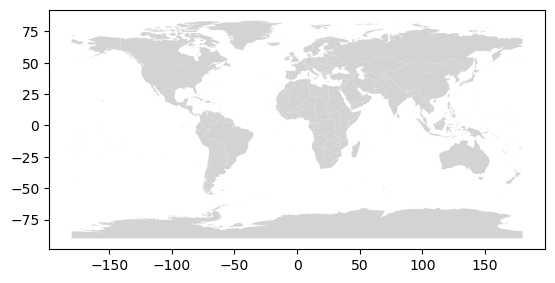

In [12]:
countries.plot(color="lightgrey")

<Axes: >

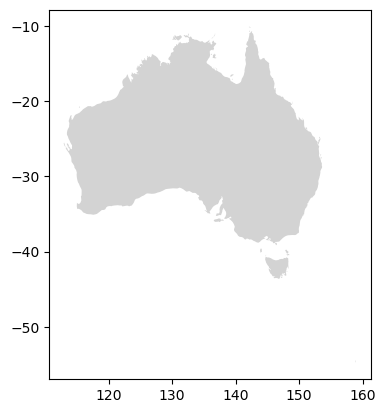

In [16]:
countries[countries["name"] == "Australia"].plot(color="lightgrey")

# Combine scatter plot with Geopandas

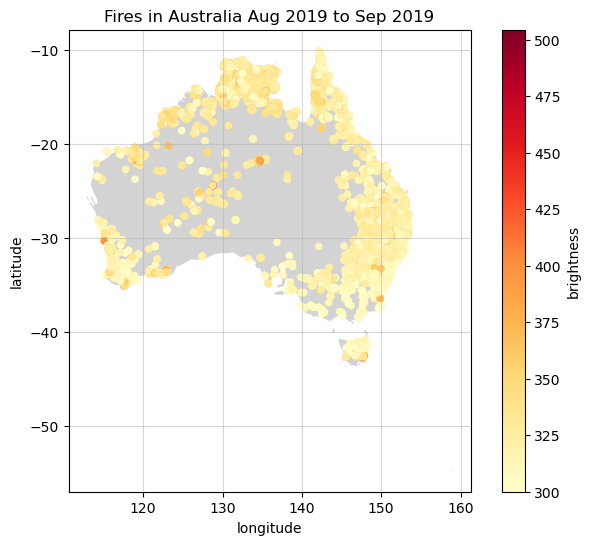

In [18]:
# initialize an axis
fig, ax = plt.subplots(figsize=(8,6))

# plot map on axis
countries[countries["name"] == "Australia"].plot(color="lightgrey", ax=ax)

# parse dates for plot's title
first_month = df["acq_date"].min().strftime("%b %Y")
last_month = df["acq_date"].max().strftime("%b %Y")

# plot points
df.plot(x="longitude", y="latitude", kind="scatter", c="brightness", colormap="YlOrRd", 
        title=f"Fires in Australia {first_month} to {last_month}", ax=ax)

# add grid
ax.grid(alpha=0.5)

plt.show()

# Bonus - extra styling

## Minor grid

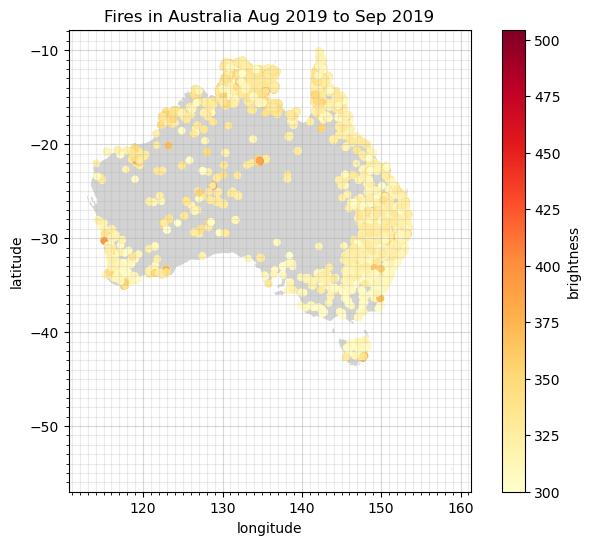

In [20]:
# get axes limits
x_lo, x_up = ax.get_xlim()
y_lo, y_up = ax.get_ylim()

# add minor ticks with a specified sapcing (deg)
deg = 1
ax.set_xticks(np.arange(np.ceil(x_lo), np.ceil(x_up), deg), minor=True)
ax.set_yticks(np.arange(np.ceil(y_lo), np.ceil(y_up), deg), minor=True)
ax.grid(which="minor", alpha=0.25)

fig

## Colorbar

In [21]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib as mpl

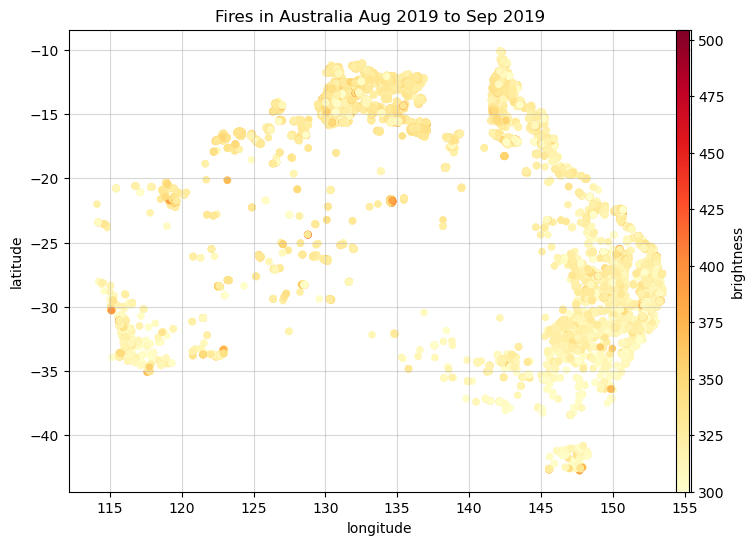

In [24]:
# initialize an axis
fig, ax = plt.subplots(figsize=(8,6))

# parse dates for plot's title
first_month = df["acq_date"].min().strftime("%b %Y")
last_month = df["acq_date"].max().strftime("%b %Y")

# plot points
df.plot(x="longitude", y="latitude", kind="scatter", c="brightness", colormap="YlOrRd", 
        title=f"Fires in Australia {first_month} to {last_month}", ax=ax, colorbar=False)

# define colorbar values
norm = mpl.colors.Normalize(vmin=df["brightness"].min(), vmax=df["brightness"].max())

# set colorbar on ax
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="2%", pad=-0.15)
mpl.colorbar.ColorbarBase(cax, cmap=mpl.cm.YlOrRd, norm=norm, label="brightness")

# add grid
ax.grid( alpha=0.5)

plt.show()

# Fires by date

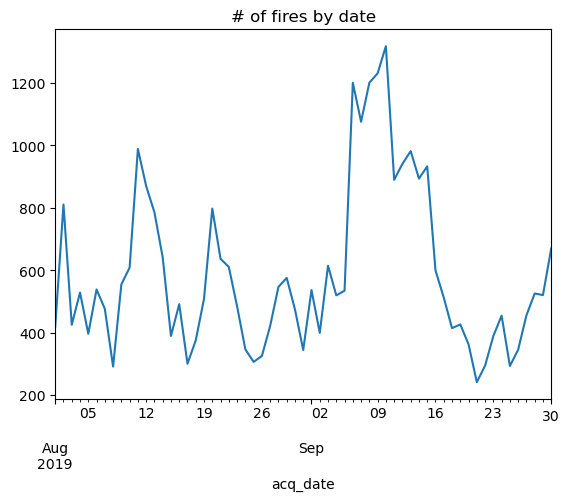

In [25]:
# create a Series containing number of events per date
count_per_date = df["acq_date"].value_counts().sort_index()
count_per_date.plot(title="# of fires by date")
plt.show()